# Case Study: House Pricing Dataset

## Libraries

### EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For mode value
from statistics import mode
# scaling numerical data
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# scaling categorical data
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# For train-test split
from sklearn.model_selection import train_test_split


## Read Dataset

In [2]:
filepath = '/content/drive/MyDrive/ICT AIML/Datasets/House_Pricing.csv'
df_house = pd.read_csv(filepath)
df_house.head(5)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [3]:
# To identify the datatype of each column
df_house.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [4]:
df_house.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [5]:
# duplicate rows
df_house.duplicated().sum()

np.int64(0)

In [6]:
# duplicate columns
df_house.columns.duplicated().sum()

np.int64(0)

## Correlation analysis

In [7]:
num_cols = df_house.select_dtypes(include = np.number)
corr_mat = num_cols.corr()
corr_mat

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,-0.016834,0.001286,0.005186,-0.012384,-0.132110,0.018525,0.013799,-0.010738,-0.005151,-0.021380,-0.016907,-0.008269,-0.001952,0.020805,-0.002888,-0.138798
Sale Price,-0.016834,1.000000,0.308463,0.525124,0.702081,0.089616,0.256941,0.580654,0.605495,0.323813,-0.054034,0.126436,-0.053198,0.306889,0.021507,0.585393,0.082445
No of Bedrooms,0.001286,0.308463,1.000000,0.515883,0.576616,0.031620,0.175429,0.349008,0.477592,0.303093,-0.154178,0.018841,-0.152656,-0.008879,0.129499,0.391649,0.029244
No of Bathrooms,0.005186,0.525124,0.515883,1.000000,0.754691,0.087758,0.500601,0.635573,0.685249,0.283774,-0.505957,0.050752,-0.204044,0.024508,0.223165,0.568606,0.087218
Flat Area (in Sqft),-0.012384,0.702081,0.576616,0.754691,1.000000,0.172809,0.353950,0.705835,0.876587,0.435230,-0.318207,0.055365,-0.199416,0.052543,0.240152,0.756357,0.183223
Lot Area (in Sqft),-0.132110,0.089616,0.031620,0.087758,0.172809,1.000000,-0.005235,0.102345,0.183512,0.015287,-0.053062,0.007717,-0.129536,-0.085672,0.229494,0.144548,0.718548
No of Floors,0.018525,0.256941,0.175429,0.500601,0.353950,-0.005235,1.000000,0.461228,0.523840,-0.245705,-0.489319,0.006338,-0.059122,0.049648,0.125391,0.279874,-0.011269
Overall Grade,0.013799,0.580654,0.349008,0.635573,0.705835,0.102345,0.461228,1.000000,0.705183,0.145266,-0.456629,0.010440,-0.185836,0.111301,0.201745,0.681338,0.107581
Area of the House from Basement (in Sqft),-0.010738,0.605495,0.477592,0.685249,0.876587,0.183512,0.523840,0.705183,1.000000,-0.051821,-0.423822,0.023301,-0.261130,-0.000866,0.343776,0.731998,0.194100
Basement Area (in Sqft),-0.005151,0.323813,0.303093,0.283774,0.435230,0.015287,-0.245705,0.145266,-0.051821,1.000000,0.133124,0.071323,0.074854,0.110554,-0.144728,0.200371,0.017276


### Plotting heatmap

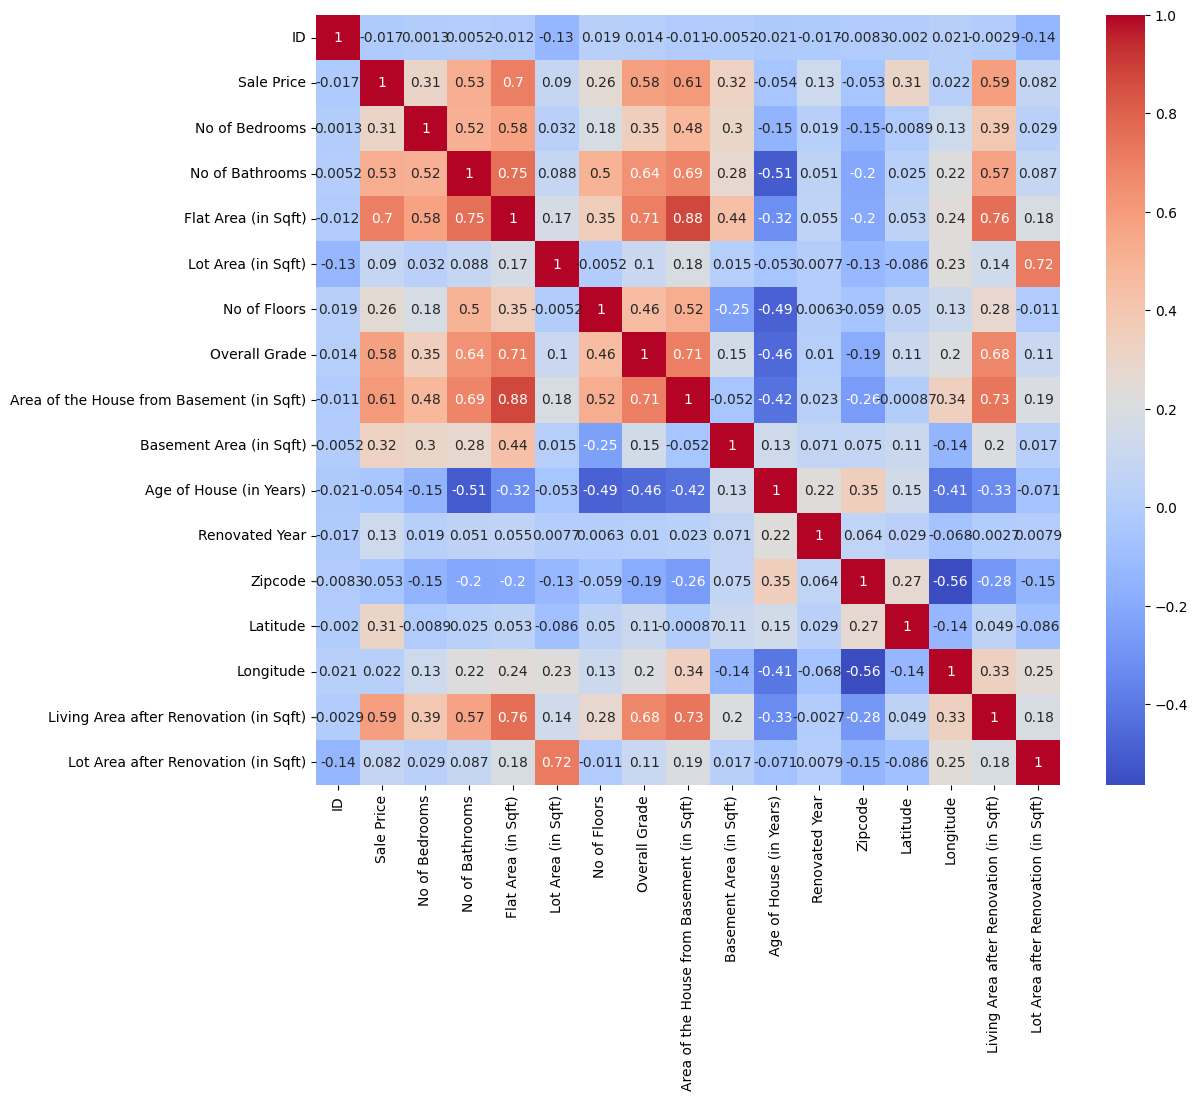

In [8]:
plt.figure(figsize= (12,10))
sns.heatmap(corr_mat, annot = True, cmap = 'coolwarm')
plt.show()

## Missing value handling

In [9]:
df_house.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [10]:
# Dropping rows which has no target values
df_house = df_house.dropna(subset=['Sale Price'])
print(df_house)

               ID Date House was Sold  Sale Price  No of Bedrooms  \
0      7129300520     14 October 2017    221900.0               3   
1      6414100192    14 December 2017    538000.0               3   
2      5631500400    15 February 2016    180000.0               2   
3      2487200875    14 December 2017    604000.0               4   
4      1954400510    15 February 2016    510000.0               3   
...           ...                 ...         ...             ...   
21608   263000018         14 May 2017    360000.0               3   
21609  6600060120    15 February 2016    400000.0               4   
21610  1523300141        14 June 2017    402101.0               2   
21611   291310100     15 January 2016    400000.0               3   
21612  1523300157     14 October 2017    325000.0               2   

       No of Bathrooms  Flat Area (in Sqft)  Lot Area (in Sqft)  No of Floors  \
0                 1.00               1180.0              5650.0           1.0   
1        

In [11]:
df_house.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


### Filling median values for numerical values

<Axes: xlabel='No of Bathrooms', ylabel='Density'>

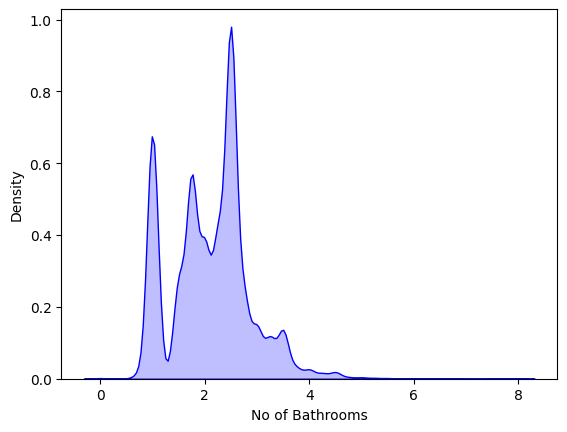

In [12]:
sns.kdeplot(df_house['No of Bathrooms'], fill ='b',color = 'b')

In [13]:
# Numerical value
df_house['No of Bathrooms'].fillna(df_house['No of Bathrooms'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/3255288673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['No of Bathrooms'].fillna(df_house['No of Bathrooms'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


<Axes: xlabel='Flat Area (in Sqft)', ylabel='Density'>

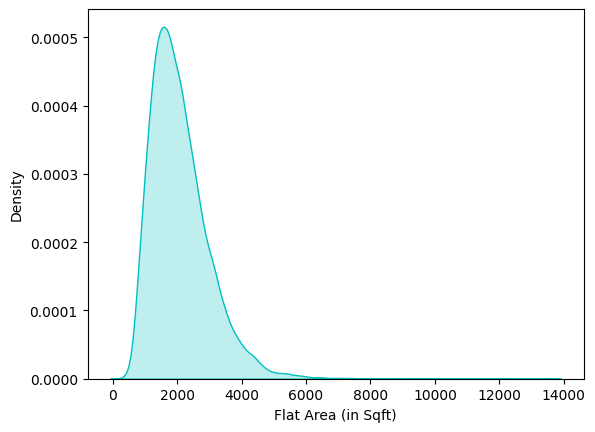

In [14]:
sns.kdeplot(df_house['Flat Area (in Sqft)'], fill ='c',color = 'c')

In [15]:
# Numerical value
df_house['Flat Area (in Sqft)'].fillna(df_house['Flat Area (in Sqft)'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/2705882219.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Flat Area (in Sqft)'].fillna(df_house['Flat Area (in Sqft)'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


<Axes: xlabel='Lot Area (in Sqft)', ylabel='Density'>

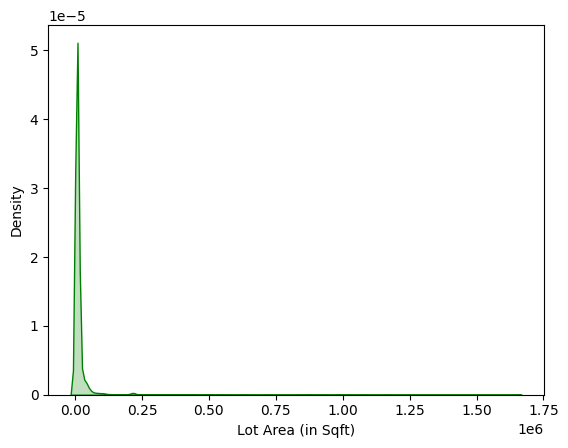

In [16]:
sns.kdeplot(df_house['Lot Area (in Sqft)'], fill ='g',color = 'g')

In [17]:
# Numerical value
df_house['Lot Area (in Sqft)'].fillna(df_house['Lot Area (in Sqft)'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/2764376931.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Lot Area (in Sqft)'].fillna(df_house['Lot Area (in Sqft)'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19485


### Dropping

In [18]:
# Dropping No of Times Visited because majority value is none

df_house.drop('No of Times Visited',inplace = True, axis =1)

In [19]:
df_house.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Density'>

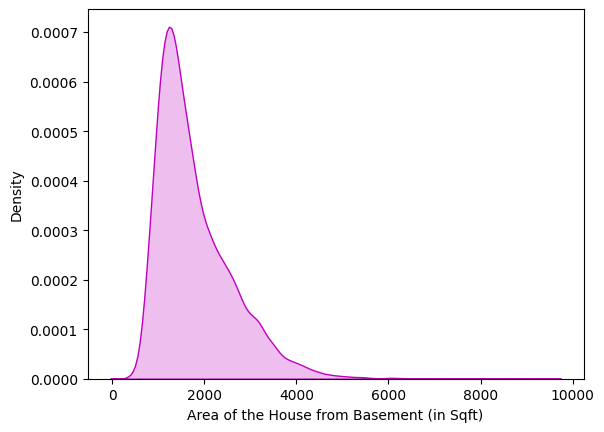

In [20]:
sns.kdeplot(df_house['Area of the House from Basement (in Sqft)'], fill = 'm', color = 'm')


In [21]:
# Numerical Value
df_house['Area of the House from Basement (in Sqft)'].fillna(df_house['Area of the House from Basement (in Sqft)'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/3583976306.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Area of the House from Basement (in Sqft)'].fillna(df_house['Area of the House from Basement (in Sqft)'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


### Filling mode value for categorical values ( Zipcode is categorical value)

<Axes: xlabel='Zipcode', ylabel='Density'>

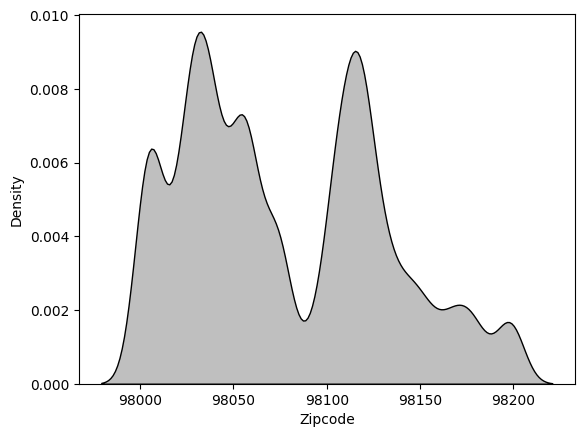

In [22]:
sns.kdeplot(df_house['Zipcode'], fill = 'k', color = 'k')


In [23]:
# Categorical value
df_house['Zipcode'].fillna(mode(df_house['Zipcode']),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/4290097003.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Zipcode'].fillna(mode(df_house['Zipcode']),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


### Again filling median value for numerical value

<Axes: xlabel='Latitude', ylabel='Density'>

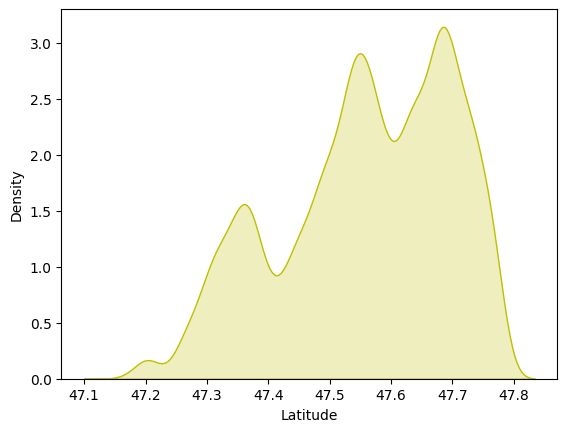

In [24]:
sns.kdeplot(df_house['Latitude'], fill = 'y', color = 'y')


In [25]:
# Numerical Value
df_house['Latitude'].fillna(df_house['Latitude'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/4240521965.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Latitude'].fillna(df_house['Latitude'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Longitude', ylabel='Density'>

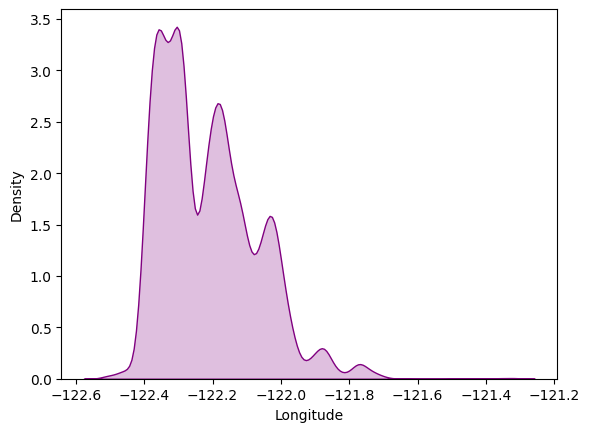

In [26]:
sns.kdeplot(df_house['Longitude'], fill = 'purple', color = 'purple')


In [27]:
# Numerical Value
df_house['Longitude'].fillna(df_house['Longitude'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/976557005.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Longitude'].fillna(df_house['Longitude'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


<Axes: xlabel='Living Area after Renovation (in Sqft)', ylabel='Density'>

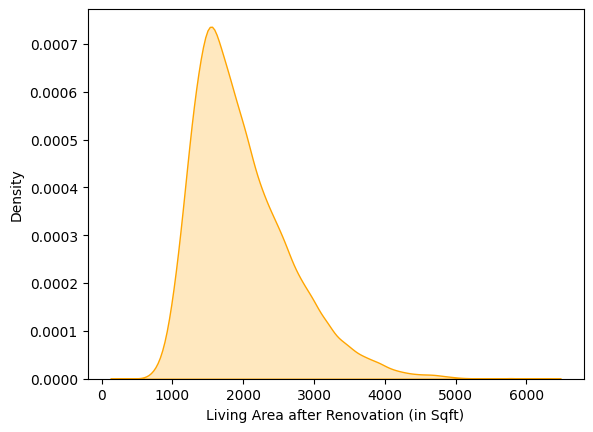

In [28]:
sns.kdeplot(df_house['Living Area after Renovation (in Sqft)'], fill = 'orange', color = 'orange')


In [29]:
# Numerical value
df_house['Living Area after Renovation (in Sqft)'].fillna(df_house['Living Area after Renovation (in Sqft)'].median(),inplace=True)
df_house.isna().sum()

/tmp/ipykernel_939/2985144799.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['Living Area after Renovation (in Sqft)'].fillna(df_house['Living Area after Renovation (in Sqft)'].median(),inplace=True)


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


## Scaling

In [30]:
#Fetch numerical columns
num_cols = df_house.select_dtypes(include =['int64','float64']).columns
print(num_cols)
# Fetch categorical columns
cat_cols = df_house.select_dtypes(include =['object']).columns
print(cat_cols)


Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [31]:
# Calculate skewness
skewness = df_house.skew(numeric_only=True)

# Sort by skewness value
print(skewness.sort_values(ascending=False))

Lot Area (in Sqft)                           13.059616
Lot Area after Renovation (in Sqft)           9.505931
Renovated Year                                4.549013
Sale Price                                    4.021472
No of Bedrooms                                1.974912
Basement Area (in Sqft)                       1.578058
Flat Area (in Sqft)                           1.472391
Area of the House from Basement (in Sqft)     1.446943
Living Area after Renovation (in Sqft)        1.108228
Longitude                                     0.884822
No of Floors                                  0.616039
No of Bathrooms                               0.511335
Age of House (in Years)                       0.469648
Zipcode                                       0.405699
Overall Grade                                 0.321409
ID                                            0.243092
Latitude                                     -0.485150
dtype: float64


In [32]:
symmetric_cols = ['ID','Overall Grade','Zipcode','Age of House (in Years)','Latitude']                                    # to be used for standard scaling
skewed_cols =['No of Bedrooms', 'No of Bathrooms','Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Renovated Year', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']          # to be used for min-max scaling

#### Standard Scaling ( For Symmetric columns )

In [33]:
# Before Standard scaling
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [34]:
# object for standard scaling
std_scaler = StandardScaler()
df_house[symmetric_cols] = std_scaler.fit_transform(df_house[symmetric_cols])


In [35]:
# After Standard Scaling
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,-0.563993,1180.0,0,0.544734,0,1.870094,-0.352576,-122.257,1340.0,5650
1,0.637358,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,-0.563993,2170.0,400,0.680915,1991,0.879534,1.161645,-122.319,1690.0,7639
2,0.365299,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,-1.468566,770.0,0,1.293731,0,-0.933379,1.283619,-122.233,2720.0,8062
3,-0.727767,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,-0.563993,1050.0,910,0.204281,0,1.085122,-0.283288,-122.393,1360.0,5000
4,-0.912987,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,0.340581,1680.0,0,-0.544715,0,-0.073647,0.409587,-122.045,1800.0,7503


#### Min-Max scaling ( For Skewed columns )

In [36]:
# Before min-max scaling
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,-0.563993,1180.0,0,0.544734,0,1.870094,-0.352576,-122.257,1340.0,5650
1,0.637358,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,-0.563993,2170.0,400,0.680915,1991,0.879534,1.161645,-122.319,1690.0,7639
2,0.365299,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,-1.468566,770.0,0,1.293731,0,-0.933379,1.283619,-122.233,2720.0,8062
3,-0.727767,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,-0.563993,1050.0,910,0.204281,0,1.085122,-0.283288,-122.393,1360.0,5000
4,-0.912987,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,0.340581,1680.0,0,-0.544715,0,-0.073647,0.409587,-122.045,1800.0,7503


In [37]:
# object for min-max scaling
minmax_scaler = MinMaxScaler()
df_house[skewed_cols] = minmax_scaler.fit_transform(df_house[skewed_cols])

In [38]:
# After min-max Scaling
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,0.0,No,Fair,-0.563993,0.097588,0.000000,0.544734,0.000000,1.870094,-0.352576,0.217608,0.161934,0.005742
1,0.637358,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,0.4,No,Fair,-0.563993,0.206140,0.082988,0.680915,0.988089,0.879534,1.161645,0.166113,0.222165,0.008027
2,0.365299,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,0.0,No,Fair,-1.468566,0.052632,0.000000,1.293731,0.000000,-0.933379,1.283619,0.237542,0.399415,0.008513
3,-0.727767,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,0.0,No,Excellent,-0.563993,0.083333,0.188797,0.204281,0.000000,1.085122,-0.283288,0.104651,0.165376,0.004996
4,-0.912987,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,0.0,No,Fair,0.340581,0.152412,0.000000,-0.544715,0.000000,-0.073647,0.409587,0.393688,0.241094,0.007871


## Encoding

In [39]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

In [40]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [41]:
# find / fix your target column
target = ['Sale Price']
feature_cat_cols = ['Date House was Sold', 'Waterfront View', 'Condition of the House']


In [42]:
# Binary feature
df_house['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [43]:
# Not a binary feature
df_house['Date House was Sold'].unique()

array(['14 October 2017', '14 December 2017', '15 February 2016',
       '14 May 2017', '14 June 2017', '15 January 2016', '15 April 2016',
       '15 March 2016', '14 July 2017', '14 August 2017',
       '14 November 2017', '14 September 2017', '15 May 2016'],
      dtype=object)

In [44]:
# Not A binary feature
df_house['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

### Label Encoding

In [45]:
# Before Label encoding
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,0.0,No,Fair,-0.563993,0.097588,0.000000,0.544734,0.000000,1.870094,-0.352576,0.217608,0.161934,0.005742
1,0.637358,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,0.4,No,Fair,-0.563993,0.206140,0.082988,0.680915,0.988089,0.879534,1.161645,0.166113,0.222165,0.008027
2,0.365299,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,0.0,No,Fair,-1.468566,0.052632,0.000000,1.293731,0.000000,-0.933379,1.283619,0.237542,0.399415,0.008513
3,-0.727767,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,0.0,No,Excellent,-0.563993,0.083333,0.188797,0.204281,0.000000,1.085122,-0.283288,0.104651,0.165376,0.004996
4,-0.912987,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,0.0,No,Fair,0.340581,0.152412,0.000000,-0.544715,0.000000,-0.073647,0.409587,0.393688,0.241094,0.007871


In [46]:
# Object
label_encoder_obj = LabelEncoder()
df_house['Waterfront View'] = label_encoder_obj.fit_transform(df_house['Waterfront View'])



In [47]:
# After Label Encoding
df_house.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,0.0,0,Fair,-0.563993,0.097588,0.000000,0.544734,0.000000,1.870094,-0.352576,0.217608,0.161934,0.005742
1,0.637358,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,0.4,0,Fair,-0.563993,0.206140,0.082988,0.680915,0.988089,0.879534,1.161645,0.166113,0.222165,0.008027
2,0.365299,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,0.0,0,Fair,-1.468566,0.052632,0.000000,1.293731,0.000000,-0.933379,1.283619,0.237542,0.399415,0.008513
3,-0.727767,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,0.0,0,Excellent,-0.563993,0.083333,0.188797,0.204281,0.000000,1.085122,-0.283288,0.104651,0.165376,0.004996
4,-0.912987,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,0.0,0,Fair,0.340581,0.152412,0.000000,-0.544715,0.000000,-0.073647,0.409587,0.393688,0.241094,0.007871


#### One Hot Encoding


In [57]:
# Before OHE (For Condition of the House)
df_house.head()


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,0.0,0,Fair,-0.563993,0.097588,0.000000,0.544734,0.000000,1.870094,-0.352576,0.217608,0.161934,0.005742
1,0.637358,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,0.4,0,Fair,-0.563993,0.206140,0.082988,0.680915,0.988089,0.879534,1.161645,0.166113,0.222165,0.008027
2,0.365299,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,0.0,0,Fair,-1.468566,0.052632,0.000000,1.293731,0.000000,-0.933379,1.283619,0.237542,0.399415,0.008513
3,-0.727767,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,0.0,0,Excellent,-0.563993,0.083333,0.188797,0.204281,0.000000,1.085122,-0.283288,0.104651,0.165376,0.004996
4,-0.912987,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,0.0,0,Fair,0.340581,0.152412,0.000000,-0.544715,0.000000,-0.073647,0.409587,0.393688,0.241094,0.007871


In [71]:
# After OHE
ohe_cols = ['Condition of the House','Date House was Sold']
df_ohe = pd.get_dummies(df_house, columns = ohe_cols, dtype= int, drop_first = True)
df_ohe.head()


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,Date House was Sold_14 June 2017,Date House was Sold_14 May 2017,Date House was Sold_14 November 2017,Date House was Sold_14 October 2017,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016
0,0.885986,221900.0,0.090909,0.12500,0.067170,0.003108,0.0,0,-0.563993,0.097588,...,0,0,0,1,0,0,0,0,0,0
1,0.637358,538000.0,0.090909,0.28125,0.172075,0.004072,0.4,0,-0.563993,0.206140,...,0,0,0,0,0,0,0,0,0,0
2,0.365299,180000.0,0.060606,0.12500,0.036226,0.005743,0.0,0,-1.468566,0.052632,...,0,0,0,0,0,0,1,0,0,0
3,-0.727767,604000.0,0.121212,0.37500,0.126038,0.002714,0.0,0,-0.563993,0.083333,...,0,0,0,0,0,0,0,0,0,0
4,-0.912987,510000.0,0.090909,0.25000,0.104906,0.004579,0.0,0,0.340581,0.152412,...,0,0,0,0,0,0,1,0,0,0


In [72]:
df_ohe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  float64
 1   Sale Price                                 21609 non-null  float64
 2   No of Bedrooms                             21609 non-null  float64
 3   No of Bathrooms                            21609 non-null  float64
 4   Flat Area (in Sqft)                        21609 non-null  float64
 5   Lot Area (in Sqft)                         21609 non-null  float64
 6   No of Floors                               21609 non-null  float64
 7   Waterfront View                            21609 non-null  int64  
 8   Overall Grade                              21609 non-null  float64
 9   Area of the House from Basement (in Sqft)  21609 non-null  float64
 10  Basement Area (in Sqft)    

## Outlier Handling

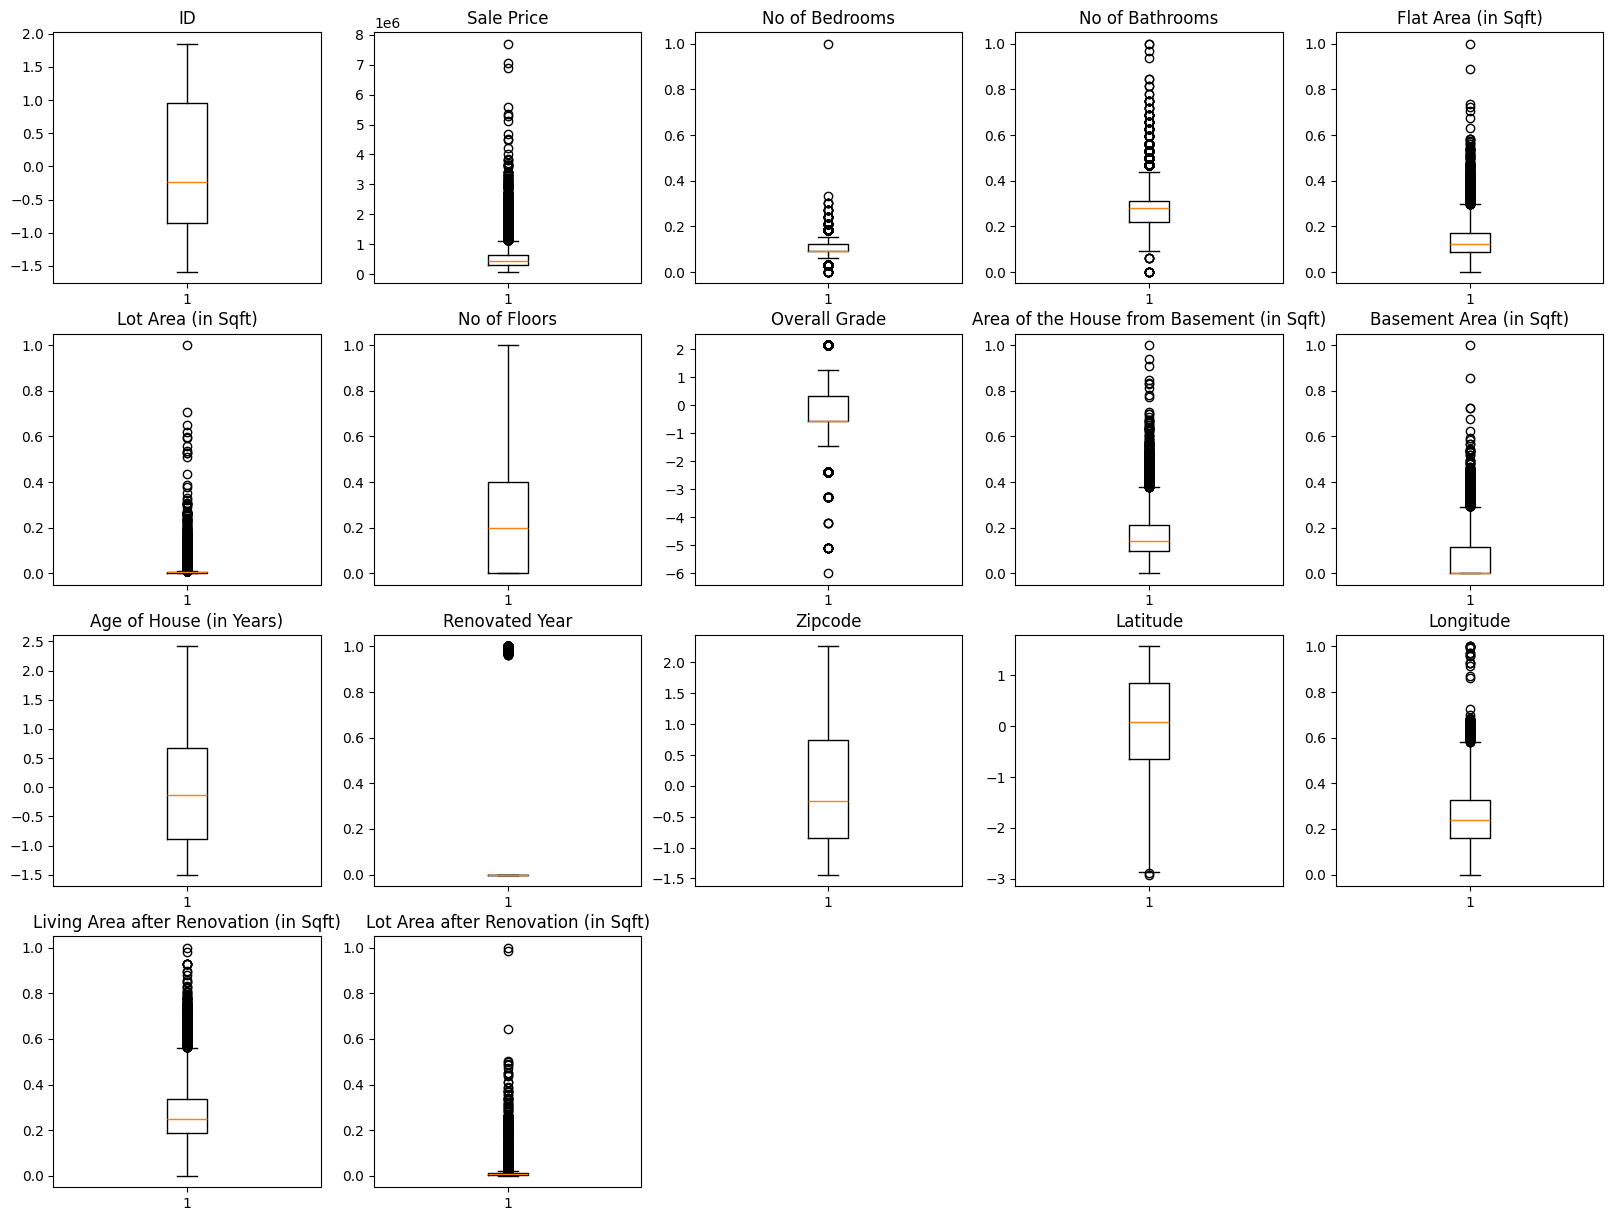

In [50]:
# Boxpolt
plt.figure(figsize = (20,15))
for i,id in enumerate(num_cols,1):
  plt.subplot(4,5,i)
  plt.boxplot(df_house[id])
  plt.title(id)

In [56]:
# Fetching columns that need outlier removal
outlier_cols = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Basement Area (in Sqft)',
    'Living Area after Renovation (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]

for col in outlier_cols:

    Q1 = df_house[col].quantile(0.25)
    Q3 = df_house[col].quantile(0.75)

    IQR = Q3 - Q1                        # calculation of IQR

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_house[(df_house[col] < lower_bound) | (df_house[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

    df_house[col] = df_house[col].clip(lower=lower_bound, upper=upper_bound) # clipping of outliers
    df_house

Flat Area (in Sqft): 0 outliers
Lot Area (in Sqft): 0 outliers
Area of the House from Basement (in Sqft): 0 outliers
Basement Area (in Sqft): 0 outliers
Living Area after Renovation (in Sqft): 0 outliers
Lot Area after Renovation (in Sqft): 0 outliers


## Train-Test Split

In [55]:
# Target variable
y = df_house['Sale Price']

# Features
X = df_house.drop('Sale Price', axis=1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17287, 19)
X_test : (4322, 19)
y_train: (17287,)
y_test : (4322,)
